# Using equivalent sources for cross-over errors

For some data types, such as gravity and magnetics, the value of the data depends on the the elevation it was collected at. For an intersection, if the two lines were flown at different altitudes, the intersection point is only the intersection in 2D space, not in 3D. To make it a true 3D intersection, we can perform upward continuation on the data so that the values of both lines represent the values that would have been observed if the flights were flown at the same altitude. We don't actually need to upward continue the entire lines, just the single points which make up the intersection.

In [ ]:
# %load_ext autoreload
# %autoreload 2


import logging

import geopandas as gpd
import numpy as np
import pandas as pd
import plotly.io as pio

import airbornegeo

# setup logging to get some additional info from the airbornegeo functions
logging.getLogger("airbornegeo").setLevel("INFO")
logging.basicConfig()
pio.renderers.default = "notebook"

/home/sungw937/airbornegeo/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

This is a subset of the BAS AGAP survey over Antarctica's Gamburtsev Subglacial Mountains. The file is download and subset in the notebook `AGAP_magnetic_survey`, and the BAS processing steps are repeated in the notebook `processing_AGAP_magnetic_survey`.

In [20]:
data_df = pd.read_csv("data/AGAP_magnetic_survey_processed_blocked.csv")
data_df = data_df[
    [
        "easting",
        "northing",
        "height",
        "line",
        "unixtime",
        "distance_along_line",
        "mag",
    ]
]

# for testing limit number of lines
data_df = data_df[~data_df.line.between(133, 142)]
data_df = data_df[~data_df.line.between(168, 176)]
data_df = data_df[
    (data_df.line.isin(data_df.line.unique()[::2])) | (data_df.line >= 143)
]

# drop rows with any nans
data_df = data_df.dropna(how="any")

# define flight lines vs tie lines with column 'tie' which is True or False
data_df["tie"] = False
data_df.loc[data_df.line >= 142, "tie"] = True

# convert dataframe into geodataframe
data_df = gpd.GeoDataFrame(
    data_df,
    geometry=gpd.points_from_xy(data_df.easting, data_df.northing),
    crs="EPSG:3031",
)

data_df.head()

,easting,northing,height,line,unixtime,distance_along_line,mag,tie,geometry
0,621099.093988,159056.748193,4110.45,1,1.229500e+09,27.181565,-33.385,False,POINT (621099.094 159056.748)
1,621206.517953,159071.301512,4114.50,1,1.229500e+09,135.587530,-35.120,False,POINT (621206.518 159071.302)
2,621313.794221,159085.113599,4117.90,1,1.229500e+09,243.749367,-36.875,False,POINT (621313.794 159085.114)
3,621420.722903,159099.184618,4120.80,1,1.229500e+09,351.600337,-38.585,False,POINT (621420.723 159099.185)
4,621527.158177,159114.303863,4123.15,1,1.229500e+09,459.104857,-40.205,False,POINT (621527.158 159114.304)


## Find intersections

Potential intersections: 100%|██████████| 670/670 [00:12<00:00, 53.79it/s]
INFO:airbornegeo:found 662 intersections


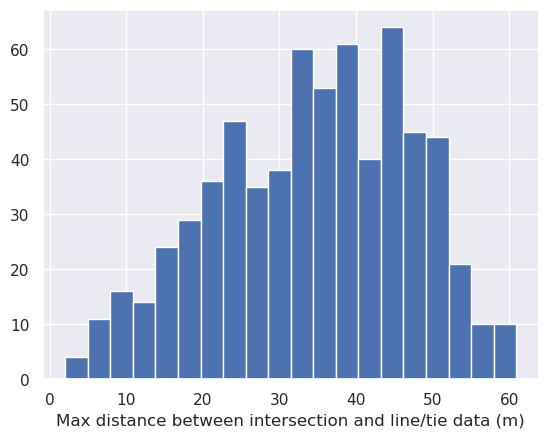

In [21]:
# calculate theoretical intersection points
inters = airbornegeo.create_intersection_table(data_df)

## Add intersections as rows to the dataframe

This just performs a cubic interpolation using windows of data on either/both sides of the intersection, we haven't used equivalent sources yet.

In [22]:
data_df, inters = airbornegeo.interpolate_intersections(
    data_df,
    inters,
    to_interp="mag",
    window_width=500,
    method="cubic",
    extrapolate=False,
)

Segments: 100%|██████████| 121/121 [00:09<00:00, 12.66it/s]


In [23]:
# re-define flight lines vs tie lines with column 'tie' which is True or False
data_df["tie"] = False
data_df.loc[data_df.line >= 142, "tie"] = True

In [24]:
lines_without_inters = airbornegeo.lines_without_intersections(data_df, inters)
lines_without_inters

[np.int64(107),
 np.int64(109),
 np.int64(129),
 np.int64(131),
 np.int64(188),
 np.int64(189),
 np.int64(190),
 np.int64(192),
 np.int64(193),
 np.int64(194),
 np.int64(203)]

In [25]:
# drop lines without intersections
data_df = data_df[~data_df.line.isin(lines_without_inters)]

## Calculate intersection cross-over errors
Now we have interpolated magnetic values for each intersecting line at the intersection points, we can calculate the cross-over errors for each intersection

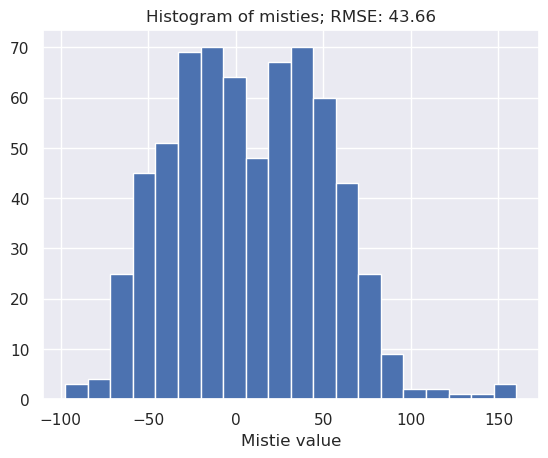

In [26]:
inters = airbornegeo.calculate_crossover_errors(
    data_df,
    inters,
    data_col="mag",
    plot_map=True,
)

## Inspect flight altitudes

In [27]:
airbornegeo.plotly_points(
    data_df[::50],
    color_col="height",
    hover_cols=["line"],
)

## Inspect flight altitude difference at intersection points

In [ ]:
# perform interpolation again, this time with height column
data_df_height, _inters_height = airbornegeo.interpolate_intersections(
    data_df,
    inters,
    to_interp="height",
    window_width=500,
    method="cubic",
    extrapolate=False,
)

# add the interpolated height values to the orginal dataframe's intersection rows
for ind, row in data_df[data_df.is_intersection].iterrows():
    height = data_df_height[
        (data_df_height.line == row.line)
        & (data_df_height.intersecting_line == row.intersecting_line)
    ].height.to_numpy()
    assert len(height) == 1
    data_df.loc[ind, "height"] = height

data_df[data_df.is_intersection].head()

Segments: 100%|██████████| 110/110 [00:09<00:00, 11.63it/s]


,easting,northing,height,line,unixtime,distance_along_line,mag,tie,geometry,is_intersection,intersecting_line,mag_interpolation_type
7453,637640.0,161826.0,4122.332685,1,NaN,16811.103180,-53.846042,False,POINT (637640 161826),True,150.0,interpolated
7454,670007.0,167673.0,4132.634362,1,NaN,49821.820318,-80.387990,False,POINT (670007 167673),True,151.0,interpolated
7455,702402.0,173414.0,4156.031337,1,NaN,82726.336899,-44.550155,False,POINT (702402 173414),True,152.0,interpolated
7456,702430.0,173419.0,4156.517464,1,NaN,82767.019948,-44.908585,False,POINT (702430 173419),True,153.0,interpolated
7457,734809.0,179103.0,4121.060700,1,NaN,115638.011785,-120.195968,False,POINT (734809 179103),True,154.0,interpolated


In [69]:
# add flight and tie heights to intersections table
inters["flight_height"] = np.nan
inters["tie_height"] = np.nan
for ind, row in inters.iterrows():
    # search data for values at intersecting lines
    flight_values = data_df[
        (data_df.line == row.line) & (data_df.intersecting_line == row.tie)
    ]
    tie_values = data_df[
        (data_df.line == row.tie) & (data_df.intersecting_line == row.line)
    ]

    # get heights
    flight_height = flight_values.height.to_numpy()
    tie_height = tie_values.height.to_numpy()

    # add to intersection table
    inters.loc[ind, "flight_height"] = flight_height
    inters.loc[ind, "tie_height"] = tie_height
inters.head()

,line,tie,geometry,max_dist,easting,northing,dist_along_flight_line,dist_along_flight_tie,flight_interpolation_type,tie_interpolation_type,mistie_0,flight_height,tie_height,inter_height_diff
0,1,143,POINT (1158153 254083),16.441255,1158153.0,254083.0,545768.072695,138071.419338,interpolated,interpolated,100.458661,4168.038983,4008.397691,938.813163
1,1,144,POINT (1190820 259865),24.124887,1190820.0,259865.0,578952.394781,131585.125284,interpolated,interpolated,32.151483,4174.500813,4010.840823,941.256295
2,1,145,POINT (1223524 265689),17.269650,1223524.0,265689.0,612181.972720,147253.496664,interpolated,interpolated,72.936553,3544.149925,3995.961216,926.376688
3,1,146,POINT (1256193 271497),31.608179,1256193.0,271497.0,645372.035087,136211.666619,interpolated,interpolated,84.125118,3564.579994,3578.174277,508.589749
4,1,147,POINT (1288901 277249),50.174377,1288901.0,277249.0,678598.170740,155115.224990,interpolated,interpolated,-7.731396,3536.160719,3545.947314,476.362786


In [70]:
inters["inter_height_diff"] = np.abs(inters["flight_height"] - inters["tie_height"])
airbornegeo.plotly_points(
    inters,
    color_col="inter_height_diff",
    hover_cols=["line", "tie"],
    robust=False,
    size=6,
)

In [71]:
airbornegeo.plot_line_and_crosses(
    data_df,
    line=148,
    x="distance_along_line",
    y=["height", "mag"],
    y_axes=[1, 2],
    plot_inters=True,
)

From the above plot showing line 148, we can see many of the cross lines were flown several hundred meters higher or lower.

## Fit equivalent sources to each line

In [72]:
eqs = airbornegeo.eq_sources_1d(
    data_df,
    data_column="mag",
    depth="default",
    damping=None,
    block_size=500,
    groupby_column="line",
)

Groups: 100%|██████████| 110/110 [01:29<00:00,  1.23it/s]


## Upward continue the intersection points to common altitudes
For each intersection point, we find the highest of the two flight elevations, and upward continue the lower data point to this height. This only changes the individual intersection point, not any of the rest of the line. You can see in the below profile of line 148 that the line data is the same between `mag` and the new column `mag_eqs`, but if you look at the intersection points (diamonds), you will see some of the have shifted slightly.

In [73]:
data_df["mag_eqs"] = airbornegeo.update_intersections_with_eq_sources(
    data_df,
    fitted_equivalent_sources=eqs,
    data_column="mag",
)

Segments: 100%|██████████| 110/110 [00:05<00:00, 19.78it/s]


In [74]:
airbornegeo.plot_line_and_crosses(
    data_df,
    line=148,
    y=["height", "mag", "mag_eqs"],
    y_axes=[1, 2, 2],
    plot_inters=[True, True, True],
)

## Recalculate cross-over errors with the updated intersection values

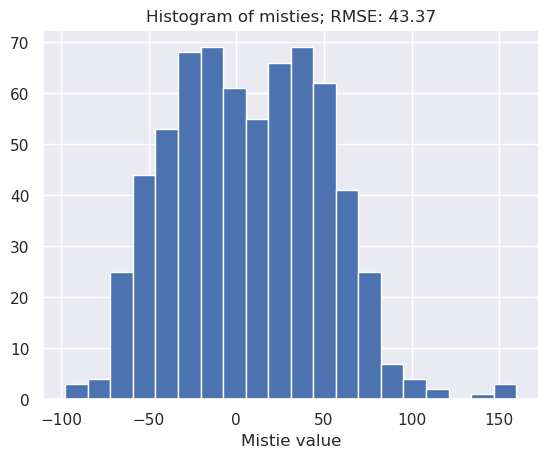

In [75]:
inters = airbornegeo.calculate_crossover_errors(
    data_df,
    inters,
    data_col="mag_eqs",
    plot_map=True,
)

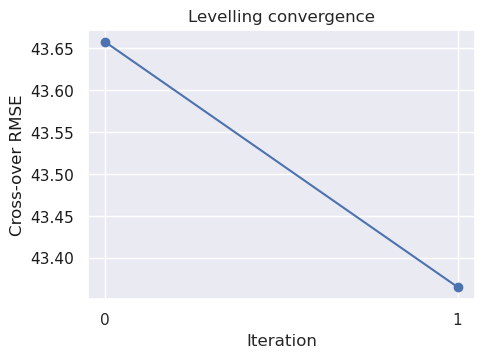

In [76]:
airbornegeo.plot_levelling_convergence(inters)

We can see that by just upward continuing the intersection points, we have slightly lowered the cross-over errors. 